In [1]:
import os
# Force TensorFlow to use optimized parallel loops and bypass duplicate DLL checks
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

print("Loading pandas...")
import pandas as pd

print("Loading numpy...")
import numpy as np

print("Loading tensorflow...")
import tensorflow as tf

print("Everything loaded successfully!")

Loading pandas...
Loading numpy...
Loading tensorflow...
Everything loaded successfully!


In [2]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
train_set = 'dataset/train'
test_set = 'dataset/test'
cnn_model = Sequential()

In [4]:
cnn_model.add(Conv2D(32, (3, 3), input_shape=(64, 64, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

cnn_model.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

cnn_model.add(Flatten())
cnn_model.add(Dense(units=128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(units=1, activation='sigmoid'))

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

c:\Users\Skanda\My-projects\CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import CSVLogger
from livelossplot.inputs.keras import PlotLossesCallback

In [6]:
csv_logger = 'log.csv'
Data_train = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, vertical_flip=True)
Data_test = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, vertical_flip=True)

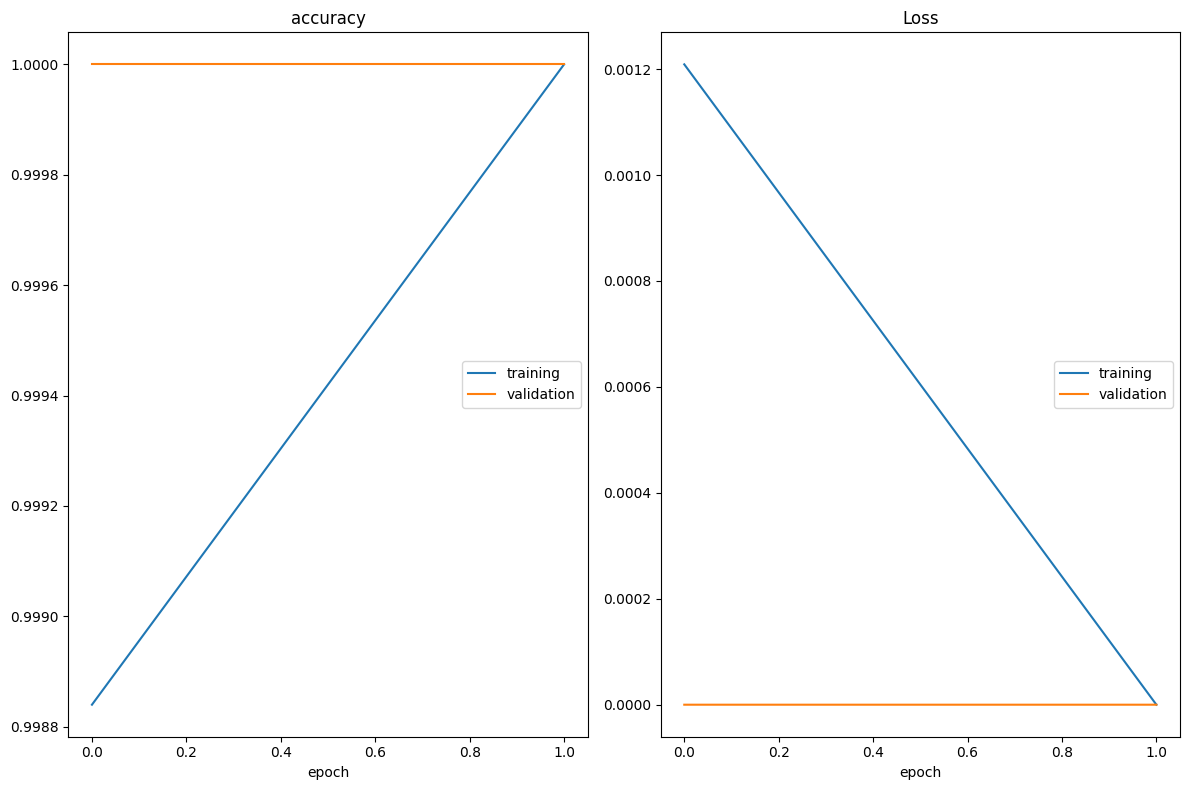

accuracy
	training         	 (min:    0.999, max:    1.000, cur:    1.000)
	validation       	 (min:    1.000, max:    1.000, cur:    1.000)
Loss
	training         	 (min:    0.000, max:    0.001, cur:    0.000)
	validation       	 (min:    0.000, max:    0.000, cur:    0.000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - accuracy: 1.0000 - loss: 3.7981e-10 - val_accuracy: 1.0000 - val_loss: 2.4208e-10


In [7]:
training_set = Data_train.flow_from_directory('archive/train', 
                                              target_size=(64, 64), 
                                              batch_size=32, 
                                              class_mode='binary')

testing_set = Data_train.flow_from_directory('archive/test', 
                                             target_size=(64, 64), 
                                             batch_size=32, 
                                             class_mode='binary')

cnn_model.fit(
    training_set, 
    epochs=2, 
    validation_data=testing_set,       
    callbacks=[
        PlotLossesCallback(), 
        CSVLogger(csv_logger, append=False, separator=";")
    ]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
{'train': 0}
cat image


<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Skanda\AppData\Local\Temp\ipykernel_10116\1239289218.py:2: SyntaxWarning: invalid escape sequence '\c'
  new_image = image.load_img('archive\cat.8428.jpg', target_size=(64,64))


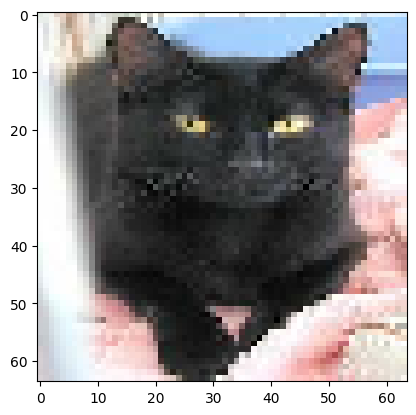

In [8]:
from keras.preprocessing import image
new_image = image.load_img('archive\cat.8428.jpg', target_size=(64,64))
plt.imshow(new_image)

new_image = image.img_to_array(new_image)
test_image = np.expand_dims(new_image, axis=0)
result = cnn_model.predict(test_image)
print(training_set.class_indices)
if result[0][0] == 1:
    print("dog image")
else:
    print("cat image")